# Part 1

## What is GRU?

GRU (Gated Recurrent Unit) is a type of Recurrent Neural Network (RNN).

It is similar to LSTM but simpler and faster.



### Simple Idea:
GRU = Simplified version of LSTM

- Fewer gates
- Faster training
- Good performance



### Why GRU?

- Learns sequence patterns
- Requires less computation than LSTM
- Works well on time series data

<img src="GRU_working_G.png" alt="Time Series info" width="900" height="500" />


## GRU for Time Series

GRU works similar to LSTM for time series forecasting.



### Steps:

Step 1:
Convert time series into sequences

Example:
[100, 110, 120] → predict 130



Step 2:
Feed sequences into GRU



Step 3:
Model learns patterns



Step 4:
Predict future values



### Why GRU?

- Faster than LSTM
- Works well with smaller datasets
- Captures sequence dependencies


<!-- <img src="GRU_for_Time_Series.png" alt="Time Series info" width="600" height="400" /> -->
<img src="GRU_model_working.png" alt="Time Series info" width="900" height="600" />



In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import warnings


warnings.filterwarnings("ignore")

e:\A_VS_CODE\a-vs-code-env\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [ ]:
# Load and Prepare Real Dataset
url = "https://raw.githubusercontent.com/mwitiderrick/stockprice/master/NSE-TATAGLOBAL.csv"
df = pd.read_csv(url)

In [8]:
df.columns

Index(['date', 'symbol', 'open', 'close', 'low', 'high', 'volume'], dtype='object')

In [ ]:
# Convert string dates to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# IMPORTANT: Stock data must be sorted chronologically from oldest to newest
df = df.sort_values('Date').reset_index(drop=True)

# We will train our model to predict the 'Close' price of the stock
dataset = df[['Close']].values
print(f"Total trading days loaded: {len(dataset)}")

Total trading days loaded: 851264


In [14]:
train = df[df['symbol'] == 'EQIX']

In [10]:
dataset

array([[ 18.040001],
       [ 53.700001],
       [ 41.509998],
       ...,
       [122.589996],
       [ 44.73    ],
       [ 54.200001]], shape=(851264, 1))

###  Data Normalization

Neural networks perform poorly with large, unscaled numbers (like stock prices ranging in hundreds or thousands). To optimize the training process, we apply a `MinMaxScaler`. This compresses all stock prices into a strict mathematical range between `0` and `1`, allowing the GRU algorithm to calculate gradients faster and more effectively.

In [23]:
# Data Preprocessing (Scaling)

# Deep learning models require input values to be between 0 and 1.
# This prevents exploding gradients during neural network training.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [16]:
scaled_data[:10]

array([[0.16584967],
       [0.16319444],
       [0.1621732 ],
       [0.14971405],
       [0.15400327],
       [0.15236928],
       [0.14562908],
       [0.14338235],
       [0.14848856],
       [0.15257353]])

###  Creating Time-Series Sequences (The Look-back Window)
Unlike simple models, a GRU requires historical context to make predictions. We transform our 1D stock data into 3D sequences `[Samples, Time_Steps, Features]`. 
By using a look-back window (e.g., 60 days), we instruct the model: *"Analyze the continuous price movement of the last 60 days to predict the closing price of the 61st day."*

In [ ]:
# Sequence Formatting (Sliding Window)

# We will look at the past 60 days of stock prices to predict day 61.
time_steps = 60 
X, y = [], []

for i in range(time_steps, len(scaled_data)):
    # Extract past 60 days
    X.append(scaled_data[i-time_steps : i, 0])
    # Extract the target value for the 61st day
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape X to 3D format: [Samples, Time Steps, Features]
# We only have 1 feature (Close price)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(f"GRU Input Shape (3D): {X.shape}")

GRU Input Shape (3D): (1975, 60, 1)


In [51]:
# Train-Test Split (Chronological)

# In time series, NEVER use random split. The past must predict the future.
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
test_dates = df['Date'].iloc[time_steps + split_index :].values

###  Designing the GRU Architecture

We build our deep learning engine using a **Gated Recurrent Unit (GRU)**. 
* **Why GRU over LSTM?** GRUs use a simplified internal gating mechanism (Update and Reset gates) compared to LSTMs. This makes them computationally lighter, faster to train, and highly effective for standard time-series data without losing performance.
* **Dropout Layers:** We explicitly add dropout layers to randomly deactivate a percentage of neurons during training. This acts as a regularization technique to strictly prevent the model from memorizing the data (Overfitting).

In [ ]:
# Build the GRU Model

model = Sequential()

# Layer 1: GRU Layer. 
# It uses 'return_sequences=True' because we want to pass the memory to the next GRU layer.
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2)) # Prevent overfitting

# Layer 2: Second GRU Layer.
# 'return_sequences=False' because this is the final memory extraction step.
model.add(GRU(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Aapka idea: Non-linear Activation Function ('relu') add karna
model.add(Dense(units=16, activation='relu'))

# Layer 3: Output Node for the final price prediction
model.add(Dense(units=1))

# Compile the model using Adam optimizer and Mean Squared Error for loss calculation
model.compile(optimizer='adam', loss='mean_squared_error')


In [82]:
#  Train the Model

# Train the model over 20 iterations (epochs)
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0069 - val_loss: 0.0051
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 8.4169e-04 - val_loss: 0.0012
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 7.3602e-04 - val_loss: 0.0012
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 6.6191e-04 - val_loss: 0.0024
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 5.7558e-04 - val_loss: 0.0014
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 5.0272e-04 - val_loss: 0.0014
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 4.9307e-04 - val_loss: 8.1692e-04
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 4.4939e-04 - val_loss: 0.0015
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 4.5833e-04 - val_loss: 0.0018
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 4.5658e-04 - val_loss: 9.2675e-04
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 3.8157e-04 - val_loss: 9.0070e-04
Epoch 12/20

In [83]:
# Inference & Inverse Scaling

# Predict prices on unseen test data
predicted_scaled = model.predict(X_test)

# Convert the predictions from 0-1 scale back to real currency values
predictions = scaler.inverse_transform(predicted_scaled)

# Convert the actual scaled targets back to real currency values for comparison
actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


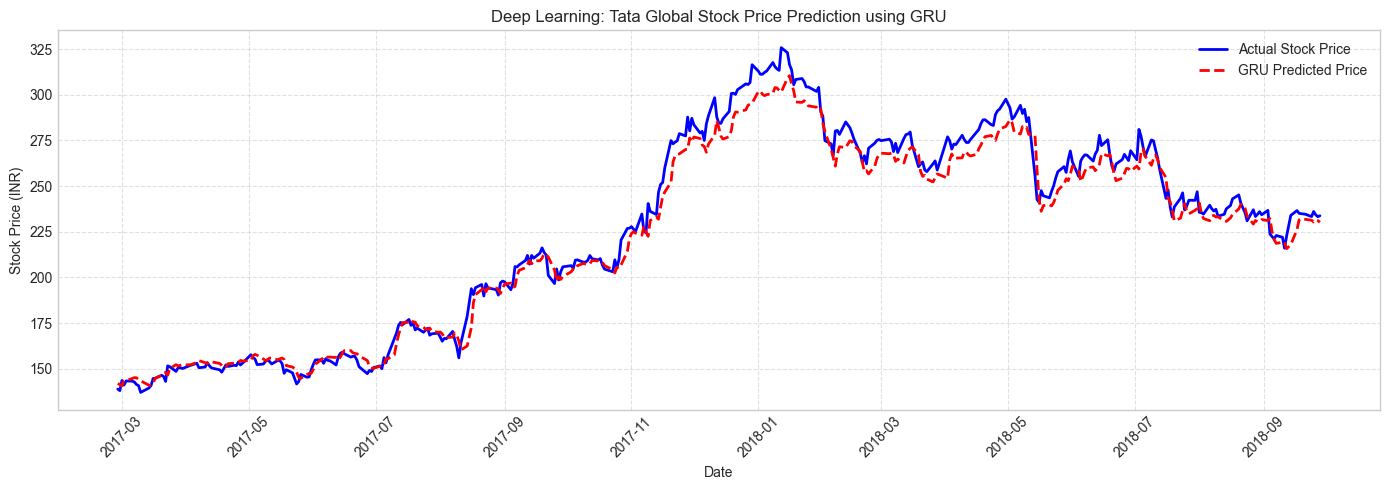

In [ ]:
import matplotlib.pyplot as plt


# Create figure
plt.figure(figsize=(14, 5))
# plt.style.use('seaborn-v0_8-whitegrid')

# Plot Actual Stock Price
plt.plot(
    test_dates,
    actuals.flatten(),
    color='blue',
    linewidth=2,
    label='Actual Stock Price'
)

# Plot GRU Predicted Stock Price
plt.plot(
    test_dates,
    predictions.flatten(),
    color='red',
    linewidth=2,
    linestyle='--',
    label='GRU Predicted Price'
)

# Labels and title
plt.title('Deep Learning: Tata Global Stock Price Prediction using GRU')
plt.xlabel('Date')
plt.ylabel('Stock Price (INR)')

# Legend and grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Rotate date labels for better readability
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

###  How to Read the Stock Forecasting Graph

This visualization compares the **Actual** historical stock prices against the **Predicted** prices generated by our GRU model. To evaluate the deep learning model's true performance, focus on these key visual indicators:

**1. The Basics:**
* **X-Axis (Bottom):** Represents the progression of time (Dates).
* **Y-Axis (Left):** Represents the Tata Global Stock Price in INR.
* **Blue Solid Line:** The real-world closing price of the stock.
* **Red Dashed Line:** Our GRU network's predicted closing price.

**2. Key Patterns to Analyze:**
* **Trend Alignment:** Does the red dashed line follow the general upward and downward waves of the blue line? If they move together, the model has successfully captured the overall market momentum.
* **Identifying The "Lag Effect":** Deep learning models in finance often struggle with sudden, unpredictable volatility. Look closely at the sharpest peaks. If the actual blue line spikes today, but the red dashed line copies that exact spike *one day later*, the model is exhibiting a "lag effect" (relying too heavily on yesterday's price rather than forecasting tomorrow's).
* **Volatility Smoothing:** You might notice the red line is slightly smoother than the jagged blue line. This happens because neural networks are designed to filter out extreme noise and predict the most statistically probable path, often missing highly erratic, single-day market anomalies.


⚙️ The End-to-End Pipeline
Data Collection & Chronological Sorting: We loaded real historical stock data (Tata Global Beverages). Unlike regular machine learning, we strictly sorted the data chronologically (oldest to newest) because, in time series, the AI must never peek into the future during training.

Data Scaling: Deep learning networks crash if fed large currency values (like ₹500 or ₹1000). We used a MinMaxScaler to perfectly compress all stock prices into a tiny mathematical window between 0 and 1.

Sequence Formatting (The 3D Sliding Window): We transformed flat spreadsheet data into blocks of time. We structured the data so the GRU network would look at a "window" of the past 60 days of stock movements to predict the exact price on the 61st day.

Model Architecture: We built a multi-layer brain. We stacked two GRU layers to extract deep financial patterns and inserted Dropout layers to randomly turn off neurons—a clever trick to prevent the AI from simply memorizing the training data (Overfitting).

Inference & Inverse Scaling: The model spat out its prediction as a tiny decimal. We applied "Inverse Scaling" to convert that mathematical number back into real, understandable currency (INR).


<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>

# Part 2